In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
def setup_chronos_for_finetuning():
    """Load Chronos model and prepare for fine-tuning"""
    try:
        from chronos import ChronosPipeline
        
        print("Loading Chronos model for fine-tuning...")
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-small",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        
        # Access the underlying T5 model for fine-tuning
        model = pipeline.model
        tokenizer = pipeline.tokenizer
        
        print("✅ Chronos model loaded and ready for fine-tuning!")
        return pipeline, model, tokenizer
        
    except Exception as e:
        print(f"❌ Error loading Chronos: {e}")
        return None, None, None

In [3]:
def load_and_preprocess_data():
    """Load và preprocess 3 files dữ liệu"""
    try:
        print("Loading data files...")
        
        # Load files
        ankhe_df = pd.read_csv("AnKhe.csv")
        kanak_df = pd.read_csv("KaNak.csv")
        rain_df = pd.read_csv("SoLieuMua_AnKhe_Kanak.csv")
        
        print(f"✅ AnKhe.csv loaded: {ankhe_df.shape}")
        print(f"✅ KaNak.csv loaded: {kanak_df.shape}")
        print(f"✅ SoLieuMua_AnKhe_Kanak.csv loaded: {rain_df.shape}")
        
        # Preprocessing
        ankhe_df["datetime"] = pd.to_datetime(
            ankhe_df["gio"].astype(str) + " " + ankhe_df["ngay"], 
            format="%H %d/%m/%Y", errors='coerce'
        )
        ankhe_clean = ankhe_df[["datetime", "luu_luong_den_ho"]].dropna()
        
        kanak_df["datetime"] = pd.to_datetime(
            kanak_df["gio"].astype(str) + " " + kanak_df["ngay"],
            format="%H %d/%m/%Y", errors='coerce'
        )
        kanak_clean = kanak_df[["datetime", "luu_luong_xa"]].dropna()
        
        rain_df["datetime"] = pd.to_datetime(rain_df["datetime"], errors='coerce')
        rain_clean = rain_df[["datetime", "hokanak135928", "hoankhe135931", "trammuavinhthuan82897"]].dropna()
        
        # Merge all data
        print("Merging datasets...")
        df = pd.merge(ankhe_clean, kanak_clean, on="datetime", how="inner")
        df = pd.merge(df, rain_clean, on="datetime", how="inner")
        
        # Create features
        df["total_rain"] = df["hokanak135928"] + df["hoankhe135931"] + df["trammuavinhthuan82897"]
        df = df.sort_values("datetime").reset_index(drop=True)
        
        print(f"✅ Data merged successfully!")
        print(f"📊 Final dataset shape: {df.shape}")
        print(f"📅 Date range: {df['datetime'].min()} to {df['datetime'].max()}")
        
        return df
        
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        return None

In [4]:
def create_time_series_dataset_2h(df, target_col="luu_luong_den_ho", sequence_length=24):
    """
    Create time series dataset for 2-hour prediction only
    
    Args:
        df: DataFrame with time series data
        target_col: target column name
        sequence_length: input sequence length (24 hours)
    
    Returns:
        X: input sequences [num_samples, sequence_length]
        y: target values for 2h later [num_samples] 
        scaler: fitted scaler
    """
    target_values = df[target_col].values
    
    # Normalize data
    scaler = StandardScaler()
    target_scaled = scaler.fit_transform(target_values.reshape(-1, 1)).flatten()
    
    X, y = [], []
    
    # Skip 2 hours ahead (prediction_offset = 2)
    prediction_offset = 2
    
    for i in range(len(target_scaled) - sequence_length - prediction_offset + 1):
        # Input sequence (24 hours)
        x_seq = target_scaled[i:i + sequence_length]
        # Target value (2 hours later)
        y_val = target_scaled[i + sequence_length + prediction_offset - 1]
        
        X.append(x_seq)
        y.append(y_val)
    
    print(f"📊 Dataset created for 2-hour prediction:")
    print(f"   Input shape: ({len(X)}, {sequence_length})")
    print(f"   Output shape: ({len(y)},) - single value 2h ahead")
    
    return np.array(X), np.array(y), scaler

In [5]:
def create_chronos_compatible_dataset(X, y):
    """Convert data to format compatible with Chronos training"""
    # Convert to tensors
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    
    return X_tensor, y_tensor


In [6]:
class ChronosFineTuner2H:
    """Fine-tuning wrapper for Chronos model - 2 hour prediction only"""
    
    def __init__(self, pipeline, model, tokenizer):
        self.pipeline = pipeline
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Move model to device
        self.model.to(self.device)
        
    def create_simple_loss_function(self):
        """Create MSE loss for regression"""
        return nn.MSELoss()
    
    def train_epoch(self, train_loader, optimizer, criterion):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(self.device), target.to(self.device)
            
            optimizer.zero_grad()
            
            try:
                batch_size, seq_len = data.shape
                
                # Create prediction head if not exists
                if not hasattr(self, 'prediction_head'):
                    self.prediction_head = nn.Sequential(
                        nn.Linear(seq_len, 128),
                        nn.ReLU(),
                        nn.Dropout(0.1),
                        nn.Linear(128, 64),
                        nn.ReLU(),
                        nn.Linear(64, 1)  # Single output for 2h prediction
                    ).to(self.device)
                    self.prediction_head.train()
                
                # Forward pass
                output = self.prediction_head(data).squeeze()
                
                # Calculate loss
                loss = criterion(output, target)
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.prediction_head.parameters(), max_norm=1.0)
                
                optimizer.step()
                total_loss += loss.item()
                num_batches += 1
                
            except Exception as e:
                print(f"Warning: Batch {batch_idx} failed: {e}")
                continue
        
        return total_loss / max(num_batches, 1)
    
    def evaluate(self, val_loader, criterion):
        """Evaluate model"""
        self.model.eval()
        if hasattr(self, 'prediction_head'):
            self.prediction_head.eval()
        
        total_loss = 0
        predictions = []
        actuals = []
        num_batches = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                try:
                    if hasattr(self, 'prediction_head'):
                        output = self.prediction_head(data).squeeze()
                        loss = criterion(output, target)
                        
                        total_loss += loss.item()
                        predictions.extend(output.cpu().numpy())
                        actuals.extend(target.cpu().numpy())
                        num_batches += 1
                except:
                    continue
        
        avg_loss = total_loss / max(num_batches, 1)
        return avg_loss, np.array(predictions), np.array(actuals)

In [7]:
def fine_tune_chronos_2h(pipeline, model, tokenizer, X_train, y_train, X_val, y_val, 
                        num_epochs=50, batch_size=32, learning_rate=0.001):
    """Fine-tune Chronos model for 2-hour prediction"""
    
    print(f"\n=== STARTING CHRONOS FINE-TUNING FOR 2-HOUR PREDICTION ===")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Input sequence length: {X_train.shape[1]} hours")
    print(f"Prediction horizon: 2 hours ahead")
    print(f"Epochs: {num_epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {learning_rate}")
    
    # Create data loaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize fine-tuner
    fine_tuner = ChronosFineTuner2H(pipeline, model, tokenizer)
    
    # Setup training
    criterion = fine_tuner.create_simple_loss_function()
    
    # Create prediction head for single output
    prediction_head = nn.Sequential(
        nn.Linear(X_train.shape[1], 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)  # Single output for 2h prediction
    ).to(fine_tuner.device)
    
    fine_tuner.prediction_head = prediction_head
    
    optimizer = optim.AdamW(prediction_head.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    print(f"\n🚀 Starting training...")
    
    for epoch in range(num_epochs):
        # Training
        train_loss = fine_tuner.train_epoch(train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        
        # Validation
        val_loss, val_predictions, val_actuals = fine_tuner.evaluate(val_loader, criterion)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(prediction_head.state_dict(), 'best_chronos_finetuned_2h.pth')
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {train_loss:.6f}')
            print(f'  Val Loss: {val_loss:.6f}')
            print(f'  LR: {optimizer.param_groups[0]["lr"]:.8f}')
            print('-' * 50)
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    # Load best model
    prediction_head.load_state_dict(torch.load('best_chronos_finetuned_2h.pth'))
    fine_tuner.prediction_head = prediction_head
    
    return fine_tuner, train_losses, val_losses

In [8]:
def evaluate_fine_tuned_model_2h(fine_tuner, X_val, y_val, scaler):
    """Evaluate fine-tuned model for 2-hour prediction and calculate metrics"""
    
    print(f"\n=== EVALUATING FINE-TUNED MODEL (2-HOUR PREDICTION) ===")
    
    # Create validation loader
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Get predictions
    criterion = nn.MSELoss()
    val_loss, predictions_scaled, actuals_scaled = fine_tuner.evaluate(val_loader, criterion)
    
    # Denormalize predictions and actuals
    predictions = scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(actuals_scaled.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    return mse, rmse, mae, r2, predictions, actuals

In [9]:
def save_fine_tuned_model_2h(fine_tuner, mse, rmse, mae, r2, predictions, actuals, 
                            train_losses, val_losses, save_dir="chronos_finetuned_2h"):
    """Save fine-tuned model and results for 2-hour prediction"""
    import os
    import json
    import pickle
    from datetime import datetime
    
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Save model weights
        model_path = os.path.join(save_dir, f"chronos_finetuned_2h_{timestamp}.pth")
        torch.save(fine_tuner.prediction_head.state_dict(), model_path)
        
        # Save results
        results = {
            "timestamp": timestamp,
            "model_info": {
                "base_model": "amazon/chronos-t5-small",
                "model_type": "chronos_finetuned_hydrology_2h",
                "training_method": "fine_tuning_with_prediction_head",
                "prediction_horizon": "2_hours_ahead"
            },
            "metrics": {
                "mse": float(mse),
                "rmse": float(rmse),
                "mae": float(mae),
                "r2": float(r2),
                "num_predictions": len(predictions)
            },
            "training_history": {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "num_epochs": len(train_losses)
            },
            "predictions": predictions.tolist(),
            "actuals": actuals.tolist()
        }
        
        # Save as JSON
        json_path = os.path.join(save_dir, f"finetuned_results_2h_{timestamp}.json")
        with open(json_path, 'w') as f:
            json.dump(results, f, indent=2)
        
        # Save as pickle
        pickle_path = os.path.join(save_dir, f"finetuned_data_2h_{timestamp}.pkl")
        with open(pickle_path, 'wb') as f:
            pickle.dump(results, f)
        
        # Save predictions CSV
        csv_path = os.path.join(save_dir, f"finetuned_predictions_2h_{timestamp}.csv")
        pred_df = pd.DataFrame({
            'actual_2h': actuals,
            'predicted_2h': predictions,
            'residual_2h': actuals - predictions,
            'absolute_error_2h': np.abs(actuals - predictions)
        })
        pred_df.to_csv(csv_path, index=False)
        
        print(f"\n✅ Fine-tuned 2H model saved successfully!")
        print(f"📁 Directory: {save_dir}")
        print(f"🤖 Model weights: {model_path}")
        print(f"📊 Results: {json_path}")
        print(f"📈 Predictions: {csv_path}")
        
        return save_dir, timestamp
        
    except Exception as e:
        print(f"❌ Save error: {e}")
        return None, None

In [10]:
def plot_predictions_2h(actuals, predictions, save_path=None, num_points=200):
    """
    Vẽ biểu đồ so sánh giữa giá trị thực tế và dự đoán cho 2h.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(actuals[:num_points], label='Giá trị thực tế (2h sau)', color='blue', alpha=0.7)
    plt.plot(predictions[:num_points], label='Giá trị dự đoán (2h sau)', color='orange', alpha=0.7)
    plt.title('So sánh dự đoán lưu lượng 2 giờ sau')
    plt.xlabel('Thời điểm (index)')
    plt.ylabel('Lưu lượng đến hồ (m³/s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Biểu đồ đã được lưu tại: {save_path}")
    
    plt.show()

=== CHRONOS FINE-TUNING FOR 2-HOUR HYDROLOGY PREDICTION ===

Loading data files...
✅ AnKhe.csv loaded: (32746, 7)
✅ KaNak.csv loaded: (32763, 7)
✅ SoLieuMua_AnKhe_Kanak.csv loaded: (36514, 9)
Merging datasets...
✅ Data merged successfully!
📊 Final dataset shape: (11949, 7)
📅 Date range: 2019-10-08 00:00:00 to 2023-07-01 23:00:00

Loading Chronos model for fine-tuning...
✅ Chronos model loaded and ready for fine-tuning!

📊 Creating time series dataset for 2-hour prediction...
📊 Dataset created for 2-hour prediction:
   Input shape: (11924, 24)
   Output shape: (11924,) - single value 2h ahead
Dataset created: X shape (11924, 24), y shape (11924,)
Train: 9539 samples, Validation: 2385 samples

=== STARTING CHRONOS FINE-TUNING FOR 2-HOUR PREDICTION ===
Training samples: 9539
Validation samples: 2385
Input sequence length: 24 hours
Prediction horizon: 2 hours ahead
Epochs: 30
Batch size: 32
Learning rate: 0.001

🚀 Starting training...
Epoch [5/30]
  Train Loss: 0.051155
  Val Loss: 0.02966

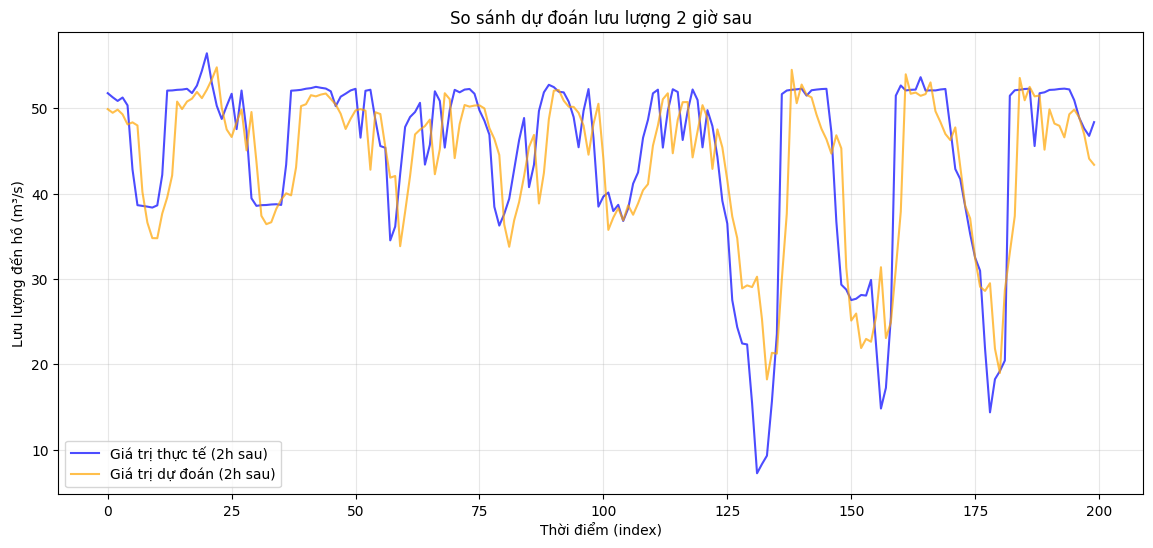

In [11]:
def main():
    """Main fine-tuning pipeline for 2-hour prediction"""
    print("=== CHRONOS FINE-TUNING FOR 2-HOUR HYDROLOGY PREDICTION ===\n")
    
    # 1. Load data
    df = load_and_preprocess_data()
    if df is None:
        return
    
    # 2. Load Chronos model
    pipeline, model, tokenizer = setup_chronos_for_finetuning()
    if pipeline is None:
        return
    
    # 3. Create time series dataset for 2-hour prediction
    print("\n📊 Creating time series dataset for 2-hour prediction...")
    X, y, scaler = create_time_series_dataset_2h(df, target_col="luu_luong_den_ho", 
                                               sequence_length=24)
    
    print(f"Dataset created: X shape {X.shape}, y shape {y.shape}")
    
    # 4. Train/validation split
    split_idx = int(len(X) * 0.8)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]
    
    print(f"Train: {len(X_train)} samples, Validation: {len(X_val)} samples")
    
    # 5. Fine-tune model
    fine_tuner, train_losses, val_losses = fine_tune_chronos_2h(
        pipeline, model, tokenizer, X_train, y_train, X_val, y_val,
        num_epochs=30, batch_size=32, learning_rate=0.001
    )
    
    # 6. Evaluate model
    mse, rmse, mae, r2, predictions, actuals = evaluate_fine_tuned_model_2h(
        fine_tuner, X_val, y_val, scaler
    )
    
    # 7. Print results
    print(f"\n" + "="*60)
    print("FINE-TUNED CHRONOS EVALUATION RESULTS (2-HOUR PREDICTION)")
    print("="*60)
    print(f"📊 Performance Metrics (2h ahead):")
    print(f"   MSE  (Mean Squared Error):     {mse:.6f}")
    print(f"   RMSE (Root Mean Squared Error): {rmse:.6f}")
    print(f"   MAE  (Mean Absolute Error):    {mae:.6f}")
    print(f"   R²   (R-squared):              {r2:.6f}")
    
    print(f"\n📈 Training Summary:")
    print(f"   Total epochs: {len(train_losses)}")
    print(f"   Final train loss: {train_losses[-1]:.6f}")
    print(f"   Final val loss: {val_losses[-1]:.6f}")
    print(f"   Best val loss: {min(val_losses):.6f}")
    
    # 8. Save model and results
    save_dir, timestamp = save_fine_tuned_model_2h(
        fine_tuner, mse, rmse, mae, r2, predictions, actuals, 
        train_losses, val_losses
    )
    
    if save_dir:
        print(f"\n🎉 2-Hour prediction fine-tuning completed successfully!")
        print(f"📁 Results saved in: {save_dir}")
        print(f"🔖 Timestamp: {timestamp}")

    # 9. Plot predictions
    plot_predictions_2h(actuals, predictions, save_path="chronos_finetuned_2h/prediction_plot_2h.png")

if __name__ == "__main__":
    main()

In [12]:
import json
with open(r'chronos_finetuned_2h\finetuned_results_2h_20250606_192322.json') as f:
    results = json.load(f)

print("📊 Final Metrics:")
print(f"MSE: {results['metrics']['mse']:.6f}")
print(f"RMSE: {results['metrics']['rmse']:.6f}")  
print(f"MAE: {results['metrics']['mae']:.6f}")
print(f"R²: {results['metrics']['r2']:.6f}")

print(f"\n📈 Training completed in {results['training_history']['num_epochs']} epochs")

📊 Final Metrics:
MSE: 63.816593
RMSE: 7.988529
MAE: 4.987067
R²: 0.900436

📈 Training completed in 30 epochs
